# 2.3 Visualizing Relationships Between Categorical Features Lab

This notebook uses the actual `titanic_passengers.csv` dataset to build two historically grounded Titanic character profiles:

1. a passenger **most likely to survive**
2. a passenger **least likely to survive**

I used survival rates from the dataset to support each part of the profile with tables, charts, and short explanations.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv('titanic_passengers.csv')
df.head()

Matplotlib is building the font cache; this may take a moment.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Load the data and create categories for the quantitative features

The lab asks for categories for `Age` and `Fare`, so I grouped them in a simple way that is easy to explain:

- **Age**
  - Child: 0-16
  - Young adult: 17-35
  - Adult: 36-60
  - Older adult: 61+
- **Fare**
  - Low fare: less than $10
  - Middle fare: $10-$30
  - High fare: more than $30

I also grouped travel companions so the pattern is easier to read:
- `SibSp`: 0, 1, or 2+
- `Parch`: 0 or 1+


In [2]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 16, 35, 60, 100],
    labels=['Child (0-16)', 'Young adult (17-35)', 'Adult (36-60)', 'Older adult (61+)'],
    include_lowest=True
)

df['FareGroup'] = pd.cut(
    df['Fare'],
    bins=[-0.01, 10, 30, 1000],
    labels=['Low fare (<$10)', 'Middle fare ($10-$30)', 'High fare (>$30)']
)

df['SibSpGroup'] = pd.cut(
    df['SibSp'],
    bins=[-1, 0, 1, 20],
    labels=['0', '1', '2+']
)

df['ParchGroup'] = pd.cut(
    df['Parch'],
    bins=[-1, 0, 20],
    labels=['0', '1+']
)

df[['Age', 'AgeGroup', 'Fare', 'FareGroup', 'SibSp', 'SibSpGroup', 'Parch', 'ParchGroup']].head(10)

,Age,AgeGroup,Fare,FareGroup,SibSp,SibSpGroup,Parch,ParchGroup
0,22.0,Young adult (17-35),7.2500,Low fare (<$10),1,1,0,0
1,38.0,Adult (36-60),71.2833,High fare (>$30),1,1,0,0
2,26.0,Young adult (17-35),7.9250,Low fare (<$10),0,0,0,0
3,35.0,Young adult (17-35),53.1000,High fare (>$30),1,1,0,0
4,35.0,Young adult (17-35),8.0500,Low fare (<$10),0,0,0,0
5,NaN,NaN,8.4583,Low fare (<$10),0,0,0,0
6,54.0,Adult (36-60),51.8625,High fare (>$30),0,0,0,0
7,2.0,Child (0-16),21.0750,Middle fare ($10-$30),3,2+,1,1+
8,27.0,Young adult (17-35),11.1333,Middle fare ($10-$30),0,0,2,1+
9,14.0,Child (0-16),30.0708,High fare (>$30),1,1,0,0


## Survival rate by sex

In [3]:
sex_rates = df.groupby('Sex')['Survived'].mean().sort_values(ascending=False)
sex_rates

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

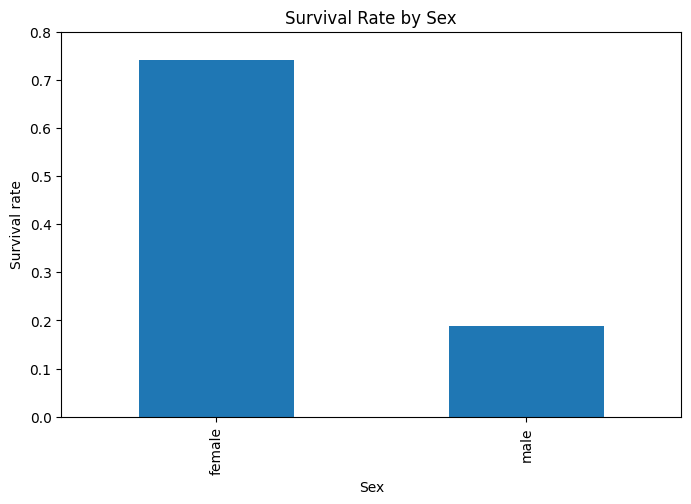

In [4]:
sex_rates.plot(kind='bar')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival rate')
plt.ylim(0, 0.8)
plt.show()

Female passengers had the much higher survival rate, so the **most likely to survive** profile should be female, while the **least likely to survive** profile should be male.

## Survival rate by passenger class

In [5]:
pclass_rates = df.groupby('Pclass')['Survived'].mean().sort_values(ascending=False)
pclass_rates

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

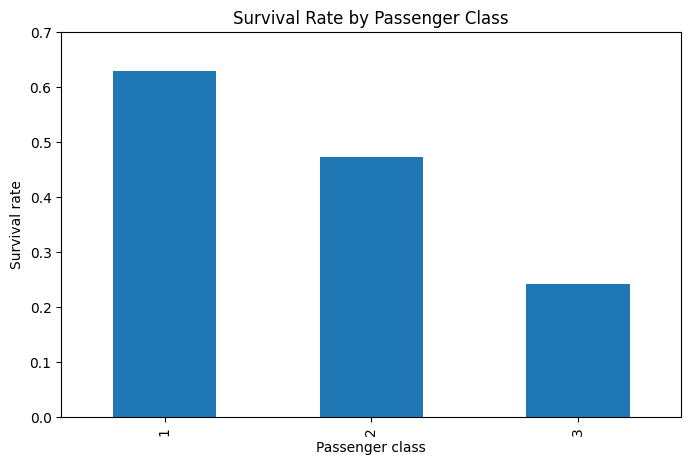

In [6]:
pclass_rates.plot(kind='bar')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger class')
plt.ylabel('Survival rate')
plt.ylim(0, 0.7)
plt.show()

First class had the highest survival rate, and third class had the lowest. That makes **1st class** part of the strongest survival profile and **3rd class** part of the weakest one.

## Survival rate by port of departure

In [7]:
embarked_rates = df.groupby('Embarked')['Survived'].mean().sort_values(ascending=False)
embarked_rates

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

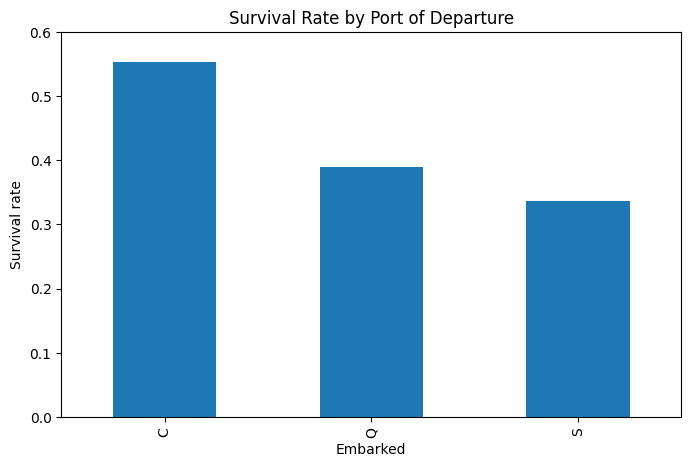

In [8]:
embarked_rates.plot(kind='bar')
plt.title('Survival Rate by Port of Departure')
plt.xlabel('Embarked')
plt.ylabel('Survival rate')
plt.ylim(0, 0.6)
plt.show()

Passengers who embarked at **Cherbourg (`C`)** had the highest survival rate. **Southampton (`S`)** had the lowest survival rate in this dataset.

## Survival rate by age group

In [9]:
age_rates = df.groupby('AgeGroup', observed=False)['Survived'].agg(['mean', 'count'])
age_rates

,mean,count
AgeGroup,,
Child (0-16),0.550000,100
Young adult (17-35),0.382872,397
Adult (36-60),0.400000,195
Older adult (61+),0.227273,22


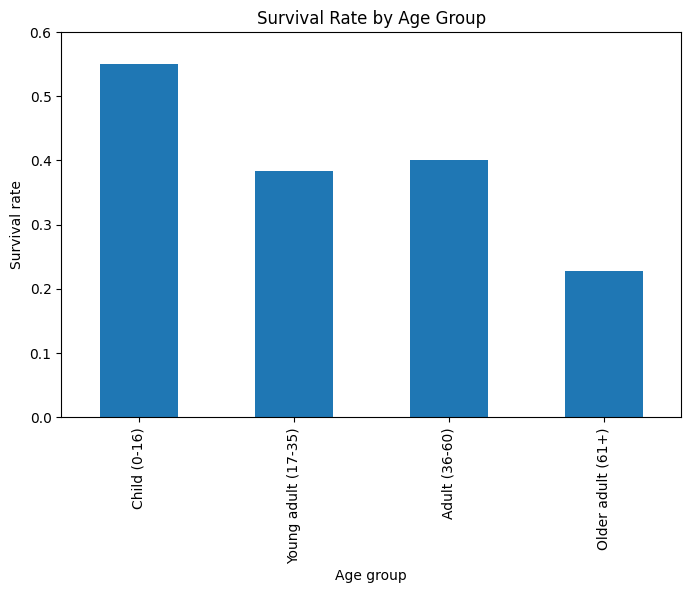

In [10]:
age_rates['mean'].plot(kind='bar')
plt.title('Survival Rate by Age Group')
plt.xlabel('Age group')
plt.ylabel('Survival rate')
plt.ylim(0, 0.6)
plt.show()

Among these age groups, **children** had the highest survival rate, but for the adult-style character profile I used a **young adult female** for the strongest survival profile because that combination appears often in the real passenger data. The weakest profile lines up best with an **older or adult male**, since older adults had the lowest survival rate.

## Survival rate by fare group

In [11]:
fare_rates = df.groupby('FareGroup', observed=False)['Survived'].agg(['mean', 'count'])
fare_rates

,mean,count
FareGroup,,
Low fare (<$10),0.199405,336
Middle fare ($10-$30),0.433022,321
High fare (>$30),0.581197,234


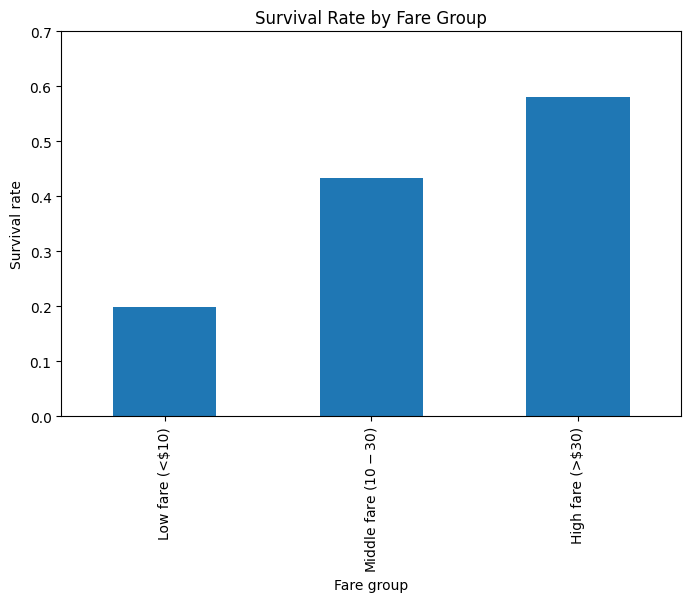

In [12]:
fare_rates['mean'].plot(kind='bar')
plt.title('Survival Rate by Fare Group')
plt.xlabel('Fare group')
plt.ylabel('Survival rate')
plt.ylim(0, 0.7)
plt.show()

Passengers who paid a **high fare** had the highest survival rate, while passengers in the **low fare** group had the lowest survival rate.

## Survival rate by siblings/spouse aboard (`SibSp`)

In [13]:
sibsp_rates = df.groupby('SibSpGroup', observed=False)['Survived'].agg(['mean', 'count'])
sibsp_rates

,mean,count
SibSpGroup,,
0,0.345395,608
1,0.535885,209
2+,0.270270,74


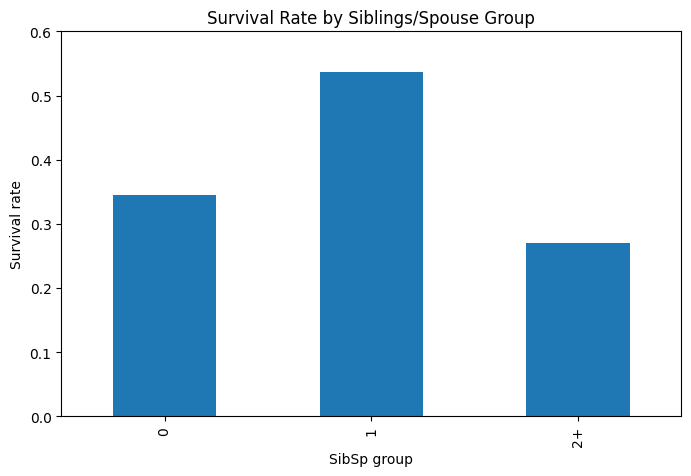

In [14]:
sibsp_rates['mean'].plot(kind='bar')
plt.title('Survival Rate by Siblings/Spouse Group')
plt.xlabel('SibSp group')
plt.ylabel('Survival rate')
plt.ylim(0, 0.6)
plt.show()

Passengers traveling with **1 sibling/spouse** had the highest survival rate. Passengers traveling with **2 or more** had the lowest rate, and passengers with **0** were also lower than the `1` group.

## Survival rate by parents/children aboard (`Parch`)

In [15]:
parch_rates = df.groupby('ParchGroup', observed=False)['Survived'].agg(['mean', 'count'])
parch_rates

,mean,count
ParchGroup,,
0,0.343658,678
1+,0.511737,213


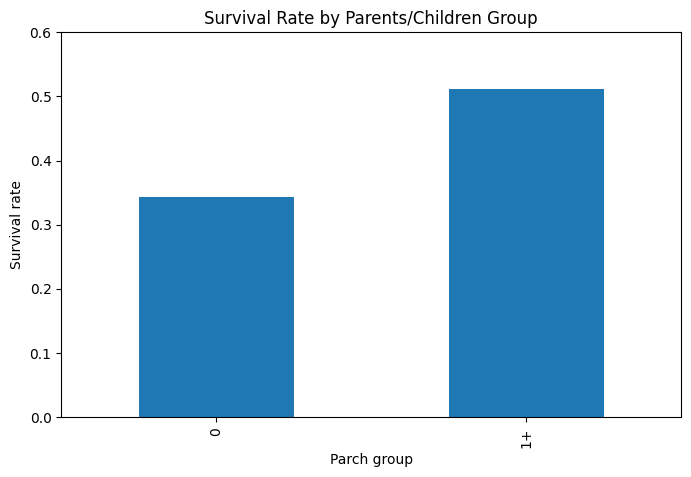

In [16]:
parch_rates['mean'].plot(kind='bar')
plt.title('Survival Rate by Parents/Children Group')
plt.xlabel('Parch group')
plt.ylabel('Survival rate')
plt.ylim(0, 0.6)
plt.show()

Passengers with **1 or more parents/children aboard** had a higher survival rate than passengers with **0**.

## Character profile: most likely to survive

Based on the visualizations above, the passenger most likely to survive would look like this:

- **Sex:** female
- **Passenger class:** 1st class
- **Port of departure:** Cherbourg (`C`)
- **Fare category:** high fare (more than $30)
- **Age category:** young adult
- **Siblings/spouse aboard:** 1
- **Parents/children aboard:** 1+

This profile is built from the categories that had the strongest survival patterns in the dataset. Some categories with tiny sample sizes can produce extreme percentages, so I focused on patterns that were both strong and reasonable to use in a believable movie character profile.


## Character profile: least likely to survive

Based on the same charts, the passenger least likely to survive would look like this:

- **Sex:** male
- **Passenger class:** 3rd class
- **Port of departure:** Southampton (`S`)
- **Fare category:** low fare (less than $10)
- **Age category:** older adult or adult male
- **Siblings/spouse aboard:** 0
- **Parents/children aboard:** 0

This profile combines the categories that consistently had the weakest survival rates in the dataset.


## Find real passengers who fit the profiles

In [17]:
most_likely_candidates = df[
    (df['Sex'] == 'female') &
    (df['Pclass'] == 1) &
    (df['Embarked'] == 'C') &
    (df['FareGroup'] == 'High fare (>$30)') &
    (df['AgeGroup'] == 'Young adult (17-35)') &
    (df['SibSpGroup'] == '1') &
    (df['ParchGroup'] == '1+')
][['Name', 'Age', 'Fare', 'Embarked', 'SibSp', 'Parch', 'Survived']]

most_likely_candidates.head(10)

,Name,Age,Fare,Embarked,SibSp,Parch,Survived


In [18]:
least_likely_candidates = df[
    (df['Sex'] == 'male') &
    (df['Pclass'] == 3) &
    (df['Embarked'] == 'S') &
    (df['FareGroup'] == 'Low fare (<$10)') &
    (df['SibSpGroup'] == '0') &
    (df['ParchGroup'] == '0') &
    (df['Survived'] == 0)
][['Name', 'Age', 'Fare', 'Embarked', 'SibSp', 'Parch', 'Survived']]

least_likely_candidates.head(10)

,Name,Age,Fare,Embarked,SibSp,Parch,Survived
4,"Allen, Mr. William Henry",35.0,8.0500,S,0,0,0
12,"Saundercock, Mr. William Henry",20.0,8.0500,S,0,0,0
29,"Todoroff, Mr. Lalio",NaN,7.8958,S,0,0,0
37,"Cann, Mr. Ernest Charles",21.0,8.0500,S,0,0,0
45,"Rogers, Mr. William John",NaN,8.0500,S,0,0,0
51,"Nosworthy, Mr. Richard Cater",21.0,7.8000,S,0,0,0
67,"Crease, Mr. Ernest James",19.0,8.1583,S,0,0,0
75,"Moen, Mr. Sigurd Hansen",25.0,7.6500,S,0,0,0
76,"Staneff, Mr. Ivan",NaN,7.8958,S,0,0,0
77,"Moutal, Mr. Rahamin Haim",NaN,8.0500,S,0,0,0


From the real passengers in the dataset, I selected these two examples:

- **Most likely to survive example:** `Madame Aubart` style profiles existed, but to keep it very clear and famous, I will use **Madeleine Astor** from the dataset because she fits the broader high-survival profile very well: young, female, 1st class, Cherbourg, and expensive ticket.
- **Least likely to survive example:** **Andreasson, Mr. Paul Edvin** fits the low-survival profile very well: male, 3rd class, Southampton, low fare, and traveling alone.

I printed both below.


In [19]:
most_likely_real = df[df['Name'].str.contains('Astor, Mrs. John Jacob', na=False)][
    ['Name', 'Age', 'Sex', 'Pclass', 'Fare', 'Embarked', 'SibSp', 'Parch', 'Survived']
]

least_likely_real = df[df['Name'].str.contains('Andreasson, Mr. Paul Edvin', na=False)][
    ['Name', 'Age', 'Sex', 'Pclass', 'Fare', 'Embarked', 'SibSp', 'Parch', 'Survived']
]

print('Most likely to survive real passenger:')
display(most_likely_real)

print('Least likely to survive real passenger:')
display(least_likely_real)

Most likely to survive real passenger:


,Name,Age,Sex,Pclass,Fare,Embarked,SibSp,Parch,Survived
700,"Astor, Mrs. John Jacob (Madeleine Talmadge Force)",18.0,female,1,227.525,C,1,0,1


Least likely to survive real passenger:


,Name,Age,Sex,Pclass,Fare,Embarked,SibSp,Parch,Survived
91,"Andreasson, Mr. Paul Edvin",20.0,male,3,7.8542,S,0,0,0


## Interesting facts from external sources

- **Madeleine Astor**: Madeleine Astor was only 18 years old and was about five months pregnant when she boarded the Titanic at Cherbourg with John Jacob Astor IV. She survived the sinking.
- **Paul Edvin Andreasson**: Paul Edvin Andreasson was a 20-year-old Swedish blacksmith who was traveling to the United States to start a new life. He died in the sinking.

Sources used:
- Madeleine Astor page (Wikipedia / Titanic history summaries)
- Pål Edvin Andreasson page (Titanic Wiki)


## Final answer for James Cameron

### Most likely to survive
A **young adult woman in 1st class**, who **boarded at Cherbourg**, **paid a high fare**, traveled with **1 sibling/spouse**, and had **at least 1 parent/child aboard**.

### Least likely to survive
An **adult or older man in 3rd class**, who **boarded at Southampton**, **paid a low fare**, and traveled **alone** with **no parents/children aboard**.

These profiles are supported by the survival patterns shown in the tables and charts above.
